In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN


In [51]:
df=pd.read_csv("../../data/raw/Zomato Dataset.csv")
df.head()


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [52]:
df.columns = df.columns.str.strip() #removes extra spaces from column names

In [53]:
print(df.columns) #displays the column names

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)'],
      dtype='object')


In [54]:
df = df[
    (df['Restaurant_latitude'] != 0) &
    (df['Delivery_location_latitude'] != 0)
]          #removes invalid rows(latitude=0)

In [55]:
df['distance'] = np.sqrt(
    (df['Restaurant_latitude'] - df['Delivery_location_latitude'])**2 +
    (df['Restaurant_longitude'] - df['Delivery_location_longitude'])**2
)   #calculates distance using euclidian formula

In [56]:
df = df[df['distance'] > 1] #removes any small distance (noise)

In [57]:
df['traffic'] = df['Road_traffic_density'].map({
    'Low':1,
    'Medium':2,
    'High':3,
    'Jam':4
})  #converting categorical into numerical

In [58]:
df['traffic'] = df['traffic'].fillna(df['traffic'].mode()[0])
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)
#filling missing values in traffic and multiple deliveries with mode and 0 respectively

# DISTANCE VS TIME

selected distance because longer distance increases delivery time

In [59]:
X = df[['distance', 'Time_taken (min)']]

In [60]:
print(X.isna().sum())

distance            0
Time_taken (min)    0
dtype: int64


In [61]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #normalizaing to prevent larger values from dominating clustering

In [62]:
from sklearn.preprocessing import StandardScaler

X = df[['distance', 'Time_taken (min)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

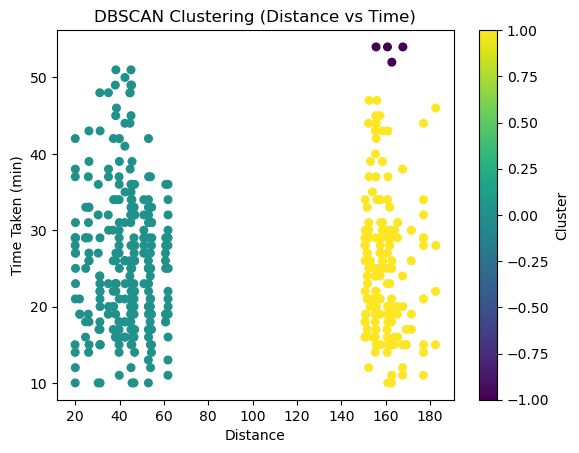

In [63]:
plt.scatter(
    df['distance'],
    df['Time_taken (min)'],
    c=df['cluster'],
    cmap='viridis',
    s=30
)

plt.xlabel("Distance")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Distance vs Time)")

plt.colorbar(label='Cluster')
plt.show()

The teal cluster (on the left, distances ~20–80) groups shorter trips with varying times.

The yellow cluster (on the right, distances ~130–180) groups longer trips with consistent times.

The dark purple points are labeled as noise or outliers — they don’t fit into any cluster because they’re too far from dense regions.

# MULTIPLE DELIVERIES VS TIME TAKEN

selected multiple deliveries because handling multiple orders increases delivery time, and time_taken to observe its effect.

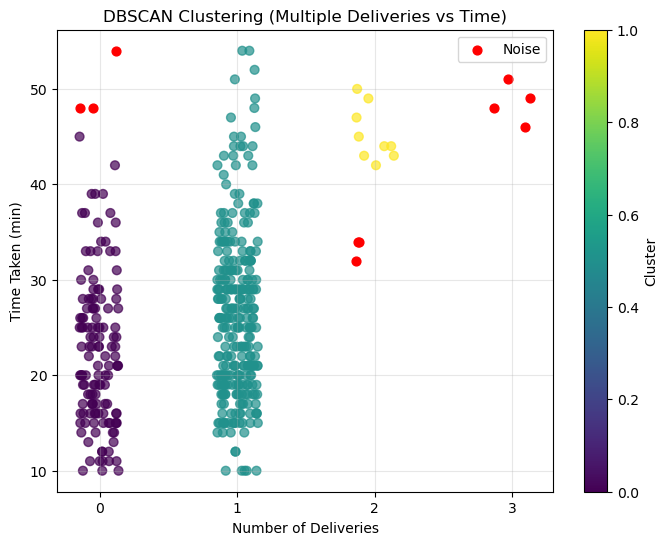

In [64]:
# Select features
X = df[['multiple_deliveries', 'Time_taken (min)']]
DBSCAN(eps=0.6, min_samples=4)
# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_scaled)

# Add jitter (VERY IMPORTANT for categorical axis)
delivery_jitter = df['multiple_deliveries'] + np.random.uniform(-0.15, 0.15, len(df))

# Plot
plt.figure(figsize=(8,6))

clusters = df['cluster'] != -1
noise = df['cluster'] == -1

# clusters
plt.scatter(
    delivery_jitter[clusters],
    df['Time_taken (min)'][clusters],
    c=df['cluster'][clusters],
    cmap='viridis',
    s=40,
    alpha=0.7
)

# noise
plt.scatter(
    delivery_jitter[noise],
    df['Time_taken (min)'][noise],
    c='red',
    label='Noise',
    s=40
)

# labels
plt.xlabel("Number of Deliveries")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Multiple Deliveries vs Time)")
plt.xticks([0,1,2,3])


plt.colorbar(label='Cluster')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

 
Clusters are formed based on density; low deliveries + low time = efficient, while high deliveries + high time = delayed. Noise points are marked as outliers

 # MULTIPLE DELIVERIES VS DISTANCE

combined distance and multiple deliveries to analyze workload impact on delivery patterns

c:\Users\diyaa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


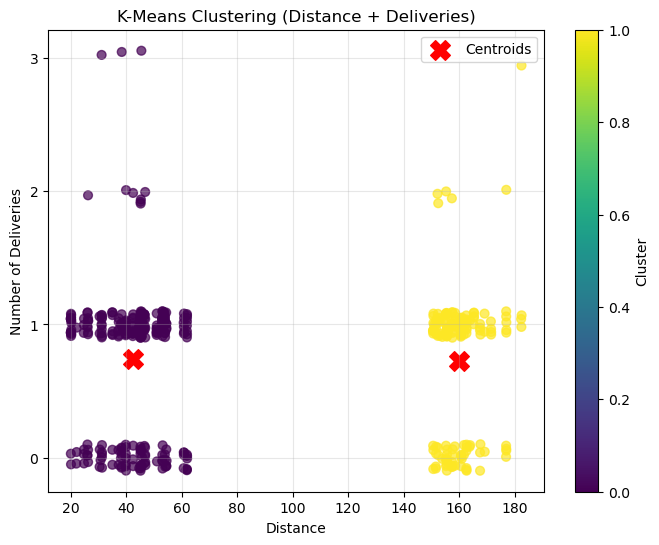

In [65]:
# Select features
X = df[['distance', 'multiple_deliveries']]

# Scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Add jitter
delivery_jitter = df['multiple_deliveries'] + np.random.uniform(-0.1, 0.1, len(df))

# Plot
plt.figure(figsize=(8,6))

plt.scatter(
    df['distance'],
    delivery_jitter,
    c=df['cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

# Centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Distance")
plt.ylabel("Number of Deliveries")
plt.title("K-Means Clustering (Distance + Deliveries)")
plt.yticks([0,1,2,3])

plt.colorbar(label='Cluster')
plt.legend()
plt.grid(alpha=0.3)

plt.show()


- **Cluster 0 (Short Distance Deliveries):**
  Orders with distance between 20–60 km show a wide range of delivery counts (0 to 3). This indicates that shorter distances allow multiple deliveries to be handled efficiently.

- **Cluster 1 (Long Distance Deliveries):**
  Orders with distance between 150–180 km mostly have 0 or 1 delivery. This suggests that longer distances limit the number of deliveries due to increased travel time.

### Key Insight:
Distance plays a significant role in determining the number of deliveries. As distance increases, the number of deliveries per trip decreases.

# FESTIVAL VS TIME

In [66]:
df['festival'] = df['Festival'].map({'No':0, 'Yes':1})

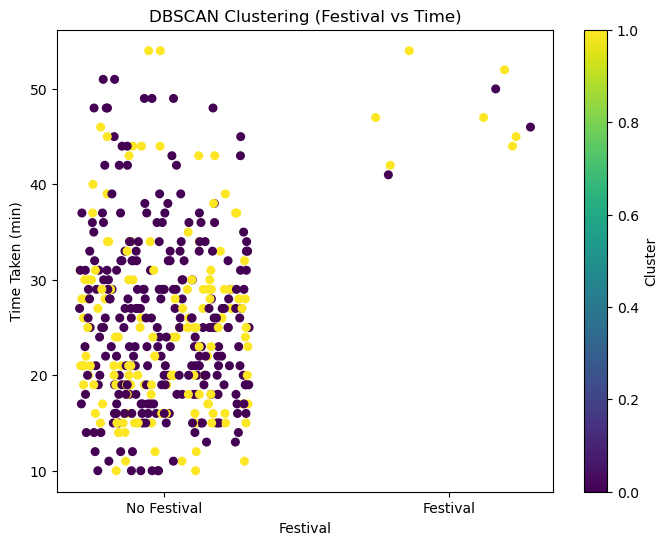

In [67]:
plt.figure(figsize=(8,6))
jitter=df['festival'] + np.random.uniform(-0.3, 0.3, len(df))
plt.scatter(
    jitter,
    df['Time_taken (min)'],
    c=df['cluster'],
    cmap='viridis',
    s=30
)

plt.xticks([0,1], ['No Festival', 'Festival'])
plt.xlabel("Festival")
plt.ylabel("Time Taken (min)")
plt.title("DBSCAN Clustering (Festival vs Time)")

plt.colorbar(label='Cluster')
plt.show()

The dataset contains significantly fewer festival observations, making it difficult to draw strong conclusions. While festival deliveries appear to have higher delivery times, the limited data suggests this may not fully represent the actual trend

Higher delivery counts are treated as noise by DBSCAN due to low density.Although higher delivery counts do not form clusters due to fewer data points, they exhibit significantly higher delivery times, reinforcing the impact of workload on delivery duration.”

K-Means assumes spherical clusters, but my data had irregular density patterns. That’s why points overlapped. DBSCAN handled it better by detecting density-based clusters